In [2]:
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as  sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) 

c:\Users\TOLU\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\TOLU\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Mar  5 19:06:55 2026).


In [3]:
df_DA_US=df[(df['job_country']== 'United States') & (df['job_title_short']== 'Data Analyst')].copy()

df_DA_US=df_DA_US.dropna(subset='salary_year_avg')

In [4]:
df_DA_US_exploded= df_DA_US.explode('job_skills')

In [5]:
df_DA_skills=df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)
df_DA_skills=df_DA_skills.rename(columns={'count':'skill_count','median':'median_salary'})

DA_job_count= len(df_DA_US)

df_DA_skills['skills_percent']=df_DA_skills['skill_count']/DA_job_count * 100

skill_percent= 5

df_DA_skills_high_demand=df_DA_skills[df_DA_skills['skills_percent']>5]

df_DA_skills_high_demand

,skill_count,median_salary,skills_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


In [6]:
%pip install adjustText

Note: you may need to restart the kernel to use updated packages.


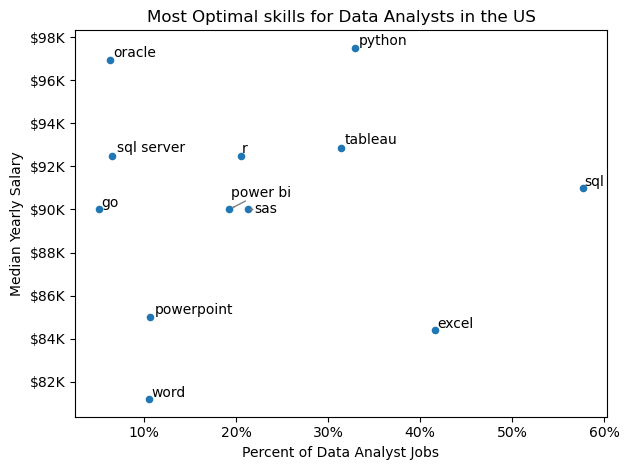

In [7]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind='scatter', x='skills_percent', y='median_salary')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(
        plt.text(
            df_DA_skills_high_demand['skills_percent'].iloc[i],
            df_DA_skills_high_demand['median_salary'].iloc[i],
            txt
        )
    )

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal skills for Data Analysts in the US')

from matplotlib.ticker import PercentFormatter
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter((lambda x, _: f'${int(x/1000)}K')))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot
plt.tight_layout()
plt.show()

In [8]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row) # convert string to dictionary
    
    for key, value in row_dict.items():
        if key in technology_dict: # if key already exists in dictionary
            technology_dict[key] += value
        else: # if key does not exist yet
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['alteryx',
  'tableau',
  'outlook',
  'spreadsheet',
  'word',
  'powerbi',
  'dax',
  'cognos',
  'microstrategy',
  'looker',
  'msaccess',
  'esquisse',
  'power bi',
  'nuix',
  'ssis',
  'excel',
  'powerpoint',
  'splunk',
  'sharepoint',
  'datarobot',
  'ssrs',
  'sas',
  'qlik',
  'ms access',
  'sap',
  'sheets',
  'spss',
  'visio'],
 'programming': ['c++',
  'mongo',
  'ocaml',
  'html',
  'scala',
  'vba',
  'lua',
  'f#',
  'lisp',
  'java',
  'apl',
  'python',
  'matlab',
  'css',
  'julia',
  'sql',
  'erlang',
  'c#',
  'shell',
  't-sql',
  'swift',
  'r',
  'visualbasic',
  'fortran',
  'no-sql',
  'powershell',
  'objective-c',
  'golang',
  'perl',
  'elixir',
  'bash',
  'clojure',
  'sas',
  'php',
  'nosql',
  'mongodb',
  'cobol',
  'vb.net',
  'groovy',
  'c',
  'visual basic',
  'haskell',
  'ruby',
  'typescript',
  'pascal',
  'rust',
  'sass',
  'solidity',
  'dart',
  'crystal',
  'delphi',
  'kotlin',
  'assembly',
  'javascript',
  

In [9]:
df_technology=pd.DataFrame(list(technology_dict.items()),columns=['technology','skills'])

df_technology=df_technology.explode('skills')
df_technology

,technology,skills
0,analyst_tools,alteryx
0,analyst_tools,tableau
0,analyst_tools,outlook
0,analyst_tools,spreadsheet
0,analyst_tools,word
...,...,...
9,sync,unify
9,sync,mattermost
9,sync,microsoft teams
9,sync,rocketchat


In [10]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on ='job_skills',right_on='skills')

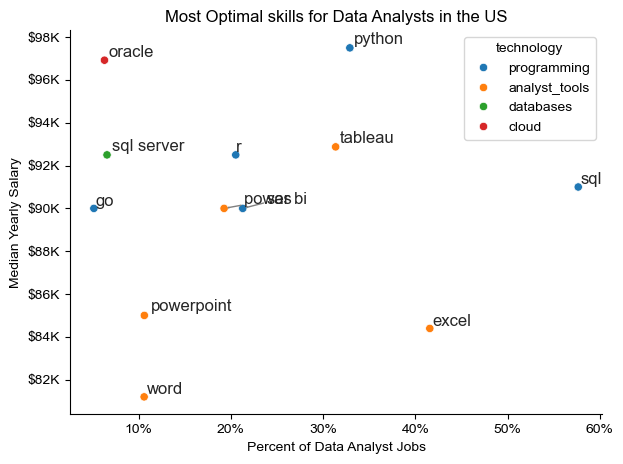

In [15]:
from adjustText import adjust_text

#df_plot.plot(kind='scatter', x='skills_percent', y='median_salary')
sns.scatterplot(
    data=df_plot,
    x='skills_percent',
    y='median_salary',
    hue= 'technology'
)
sns.despine()
sns.set_theme(style='ticks')


# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(
        plt.text(
            df_DA_skills_high_demand['skills_percent'].iloc[i],
            df_DA_skills_high_demand['median_salary'].iloc[i],
            txt
        )
    )

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal skills for Data Analysts in the US')

from matplotlib.ticker import PercentFormatter
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter((lambda x, _: f'${int(x/1000)}K')))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot
plt.tight_layout()
plt.show()